In [27]:
from sklearn.datasets import fetch_openml
adult=fetch_openml('adult', version=2, as_frame=True)
df=adult.frame

In [28]:
mapping = {'<=50K': 0, '>50K': 1}

df['target'] = df['class'].map(mapping)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df.shape
print(df.info())
print(df.describe())
print(df['class'].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
 15  target          48842 non-null  category
dtypes: category(10), int64(6)
memory usage: 2.7 MB
None
                a

Preprocessing

In [30]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import numpy as np
df.replace('?',np.nan,inplace=True)

#split

x=df.drop("target",axis=1)
y=df["target"]
x_remain,x_test,y_remain,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
x_train,x_dev,y_train,y_dev=train_test_split(x_remain,y_remain,test_size=0.10,random_state=42,stratify=y_remain)

#feature types

numeric_features = x.select_dtypes(include=["int64","float"]).columns

categorical_features = x.select_dtypes(include=["object","category"]).columns

# pipelines

numeric_pipeline=Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_pipeline=Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

# columntransformer
preprocessor= ColumnTransformer([("num",numeric_pipeline,numeric_features),(
"cat",
categorical_pipeline,
categorical_features
)])

In [36]:
#model training

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

logistic_pipeline=Pipeline(steps=[("preprocessor",preprocessor),('classifier',LogisticRegression(random_state=42,solver="liblinear"))])
tree_pipeline=Pipeline(steps=[("preprocessor",preprocessor),('classifier',DecisionTreeClassifier(random_state=42))])

In [37]:
#training

logistic_pipeline.fit(
x_train,
y_train
)

tree_pipeline.fit(
x_train,
y_train
)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme


--- MODEL PERFORMANCE COMPARISON ---
   Metric  Logistic Regression  Decision Tree  Day 1 Baseline (Most Frequent)
 Accuracy                  1.0            1.0                            0.76
Precision                  1.0            1.0                            0.00
   Recall                  1.0            1.0                            0.00
 F1 Score                  1.0            1.0                            0.00
  ROC AUC                  1.0            1.0                            0.50
   PR AUC                  1.0            1.0                            0.24


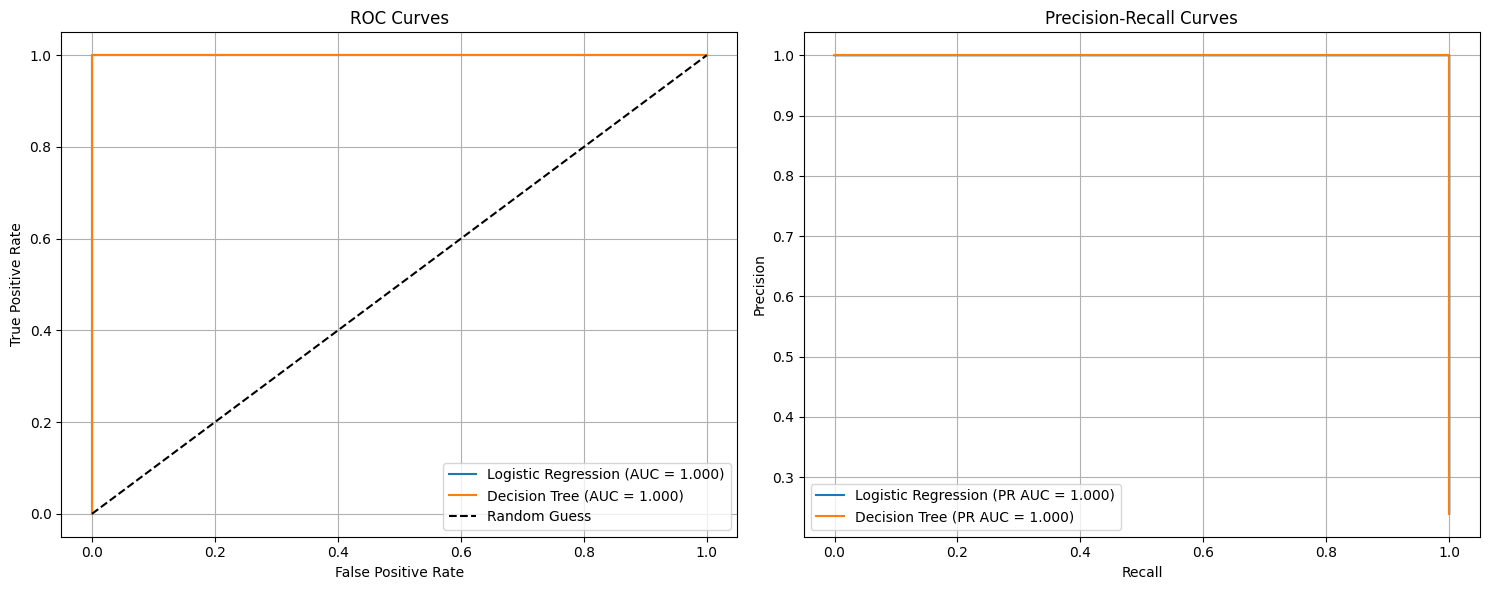

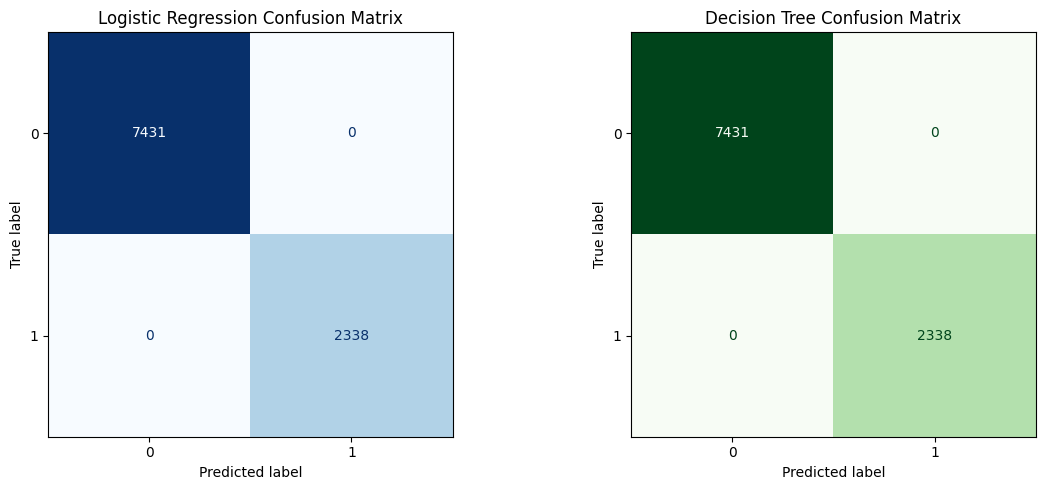


--- TOP 10 POSITIVE COEFFICIENTS (Higher income drivers) ---
                               Feature  Coefficient
                       cat__class_>50K     7.069966
                     num__capital-gain     0.523252
cat__marital-status_Married-civ-spouse     0.412825
                    num__education-num     0.360701
                cat__relationship_Wife     0.289353
       cat__occupation_Exec-managerial     0.225226
                   num__hours-per-week     0.174079
                              num__age     0.173171
             cat__relationship_Husband     0.137997
                     num__capital-loss     0.128681

--- TOP 10 NEGATIVE COEFFICIENTS (Lower income drivers) ---
                          Feature  Coefficient
     cat__marital-status_Divorced    -0.157946
  cat__relationship_Not-in-family    -0.158039
  cat__occupation_Farming-fishing    -0.167447
  cat__workclass_Self-emp-not-inc    -0.186188
    cat__occupation_Other-service    -0.215721
      cat__relationship

: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Model predictions (hard targets & probability scores)
y_pred_log = logistic_pipeline.predict(x_test)
y_prob_log = logistic_pipeline.predict_proba(x_test)[:, 1]

y_pred_tree = tree_pipeline.predict(x_test)
y_prob_tree = tree_pipeline.predict_proba(x_test)[:, 1]

# Create comparison table (including baseline dummy/previous metrics if you have them)
metrics_dict = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log, pos_label=1), # Assumes binary 1/0 or custom encoding
        recall_score(y_test, y_pred_log, pos_label=1),
        f1_score(y_test, y_pred_log, pos_label=1),
        roc_auc_score(y_test, y_prob_log),
        average_precision_score(y_test, y_prob_log)
    ],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree, pos_label=1),
        recall_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        roc_auc_score(y_test, y_prob_tree),
        average_precision_score(y_test, y_prob_tree)
    ],
    "Day 1 Baseline (Most Frequent)": [0.76, 0.00, 0.00, 0.00, 0.50, 0.24] # Replace with your actual Day 1 values
}

comparison_df = pd.DataFrame(metrics_dict)
print("\n--- MODEL PERFORMANCE COMPARISON ---")
print(comparison_df.to_string(index=False))

# --- PLOTS: ROC & Precision-Recall Curves ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
axes[0].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})')
axes[0].plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True)

# Plot Precision-Recall Curves
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_tree, recall_tree, _ = precision_recall_curve(y_test, y_prob_tree)
axes[1].plot(recall_log, precision_log, label=f'Logistic Regression (PR AUC = {average_precision_score(y_test, y_prob_log):.3f})')
axes[1].plot(recall_tree, precision_tree, label=f'Decision Tree (PR AUC = {average_precision_score(y_test, y_prob_tree):.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


# TASK 4: Interpretability Check

# 1. Logistic Regression: Map coefficients
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\n--- TOP 10 POSITIVE COEFFICIENTS (Higher income drivers) ---")
print(coef_df.head(10).to_string(index=False))

print("\n--- TOP 10 NEGATIVE COEFFICIENTS (Lower income drivers) ---")
print(coef_df.tail(10).to_string(index=False))


# 2. Decision Tree Evaluation
dt_model = tree_pipeline.named_steps["classifier"]
print("\n--- DECISION TREE STATISTICS ---")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Training Score (Accuracy): {tree_pipeline.score(x_train, y_train):.4f}")
print(f"Test Score (Accuracy): {tree_pipeline.score(x_test, y_test):.4f}")

#Export top 3 splits logic
# (To limit output complexity, we restrict max_depth display to 2 levels which captures the first 3 splits)
tree_rules = export_text(dt_model, max_depth=2, feature_names=list(feature_names))
print("\n--- TOP 3 SPLITS LOGIC ---")
print(tree_rules)